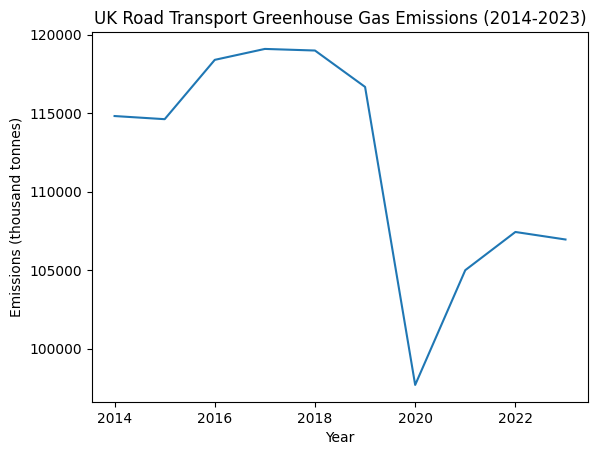

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

df = pd.read_excel(
    '../data/atmospheric_and_road_transport_emissions.xlsx',
    sheet_name='Table',
    skiprows=5,        # skips the title and notes rows at the top
    usecols=[0, 4],    # column 0 = Year, column 4 = Total greenhouse gases
    nrows=34           # reads exactly 34 rows of data (1990 to 2023)
)

# Rename the columns cleanly
df.columns = ['Year', 'Total greenhouse gases']

df = df[df['Year'] >= 2014]

# Reset the index so it starts from 0 cleanly
df = df.reset_index(drop=True)

plt.plot(df['Year'], df['Total greenhouse gases'])

plt.title('UK Road Transport Greenhouse Gas Emissions (2014-2023)')
plt.xlabel('Year')
plt.ylabel('Emissions (thousand tonnes)')

plt.show()

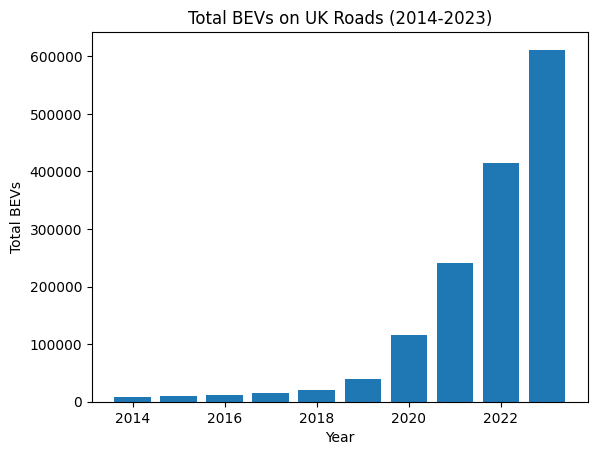

In [19]:
q4_columns = [
    '2014 Q4', '2015 Q4', '2016 Q4', '2017 Q4', '2018 Q4', '2019 Q4',
    '2020 Q4', '2021 Q4', '2022 Q4', '2023 Q4'
]

df_bev = pd.read_excel(
    '../data/veh0132.xlsx',
    sheet_name='VEH0132',
    skiprows=4,
    nrows=1,
    usecols=q4_columns
)

df_bev = df_bev.apply(pd.to_numeric, errors='coerce')

# Reverse so oldest year is first
q4_series = df_bev.iloc[0][::-1]

# Extract years
years = [int(col.split(' ')[0]) for col in q4_series.index]

# Build clean table - no diff() this time, just raw totals
df_final = pd.DataFrame({
    'Year': years,
    'Total BEVs on UK Roads': q4_series.values.astype(int)
})

pd.set_option('display.max_rows', None)

plt.bar(df_final['Year'], df_final['Total BEVs on UK Roads'])

plt.title('Total BEVs on UK Roads (2014-2023)')
plt.xlabel('Year')
plt.ylabel('Total BEVs')

plt.show()

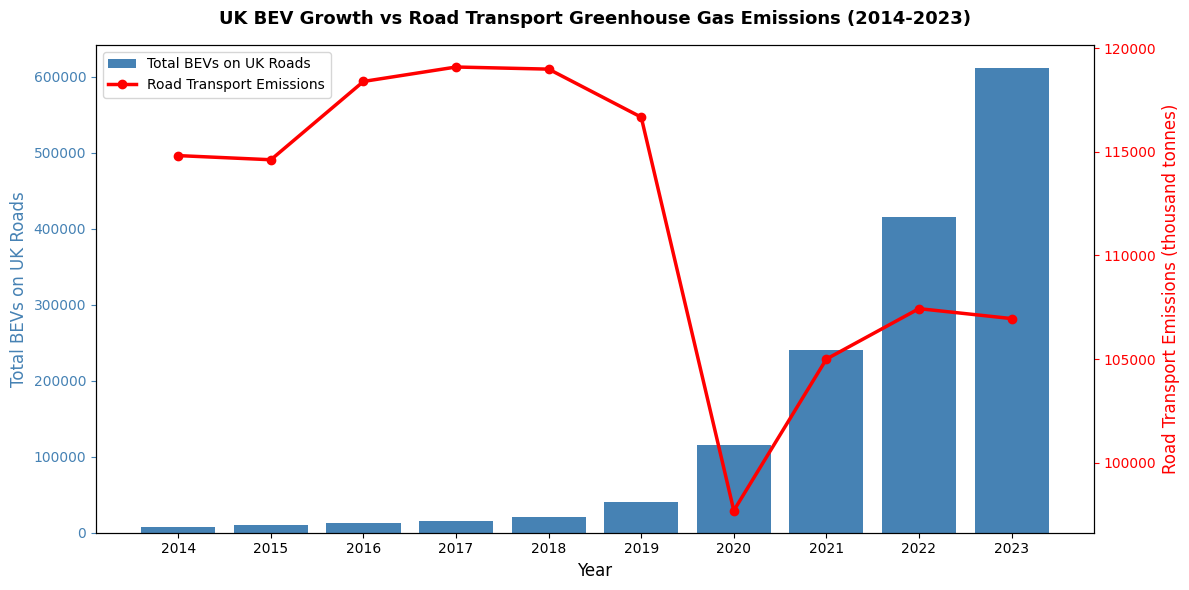

In [22]:
# Filter emissions data to match BEV years (2014-2023)
df_emissions_filtered = df[df['Year'] >= 2014]

# Create the figure and first axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bars on left axis (BEVs)
ax1.bar(
    df_final['Year'],
    df_final['Total BEVs on UK Roads'],
    color='steelblue',
    label='Total BEVs on UK Roads'
)

# Create right axis sharing same x-axis
ax2 = ax1.twinx()

# Plot line on right axis (emissions)
ax2.plot(
    df_emissions_filtered['Year'],
    df_emissions_filtered['Total greenhouse gases'],
    color='red',
    linewidth=2.5,
    marker='o',
    markersize=6,
    label='Road Transport Emissions'
)

# Labels
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total BEVs on UK Roads', fontsize=12, color='steelblue')
ax2.set_ylabel('Road Transport Emissions (thousand tonnes)', fontsize=12, color='red')

# Colour the y axis tick numbers to match their dataset
ax1.tick_params(axis='y', colors='steelblue')
ax2.tick_params(axis='y', colors='red')

# Title
ax1.set_title(
    'UK BEV Growth vs Road Transport Greenhouse Gas Emissions (2014-2023)',
    fontsize=13,
    fontweight='bold',
    pad=15
)

# Add a legend for both axes combined
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Set x axis to show every year
ax1.set_xticks(df_final['Year'])

plt.tight_layout()
plt.show()